# 🤖 CIFAKE: Real vs AI-Generated Image Detector
**Dataset:** [CIFAKE](https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images) — 60,000 real images (CIFAR-10) + 60,000 AI-generated synthetic images (Stable Diffusion)

**Task:** Binary classification — `REAL` vs `FAKE`

**Models:**
- CNN with residual blocks
- Vision Transformer (ViT) from scratch
- **Hybrid: CNN as ViT Patch Embedder** ← new

---
**Setup:** Run the dataset download cell below — it uses `kagglehub` which works out of the box on Colab (no API key file needed, just authenticate when prompted).

## 1. Install & Import Dependencies

In [13]:
!pip install torch torchvision einops matplotlib seaborn scikit-learn -q

In [14]:
from pathlib import Path

# Dataset folder is in the same directory as this notebook
DATA_ROOT = Path('./cifake')
assert DATA_ROOT.exists(), f'Could not find {DATA_ROOT.resolve()} — make sure the cifake/ folder is in the same directory as this notebook.'
print(f'Using dataset at: {DATA_ROOT.resolve()}')
print('Contents:', [p.name for p in DATA_ROOT.iterdir()])

Using dataset at: C:\Users\praji\Desktop\AI_Image_detector\cifake
Contents: ['test', 'train']


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve,
    f1_score, roc_auc_score
)
from einops import rearrange

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
torch.manual_seed(42)

Using device: cpu


## 2. Dataset Loading

In [5]:
# DATA_ROOT = Path('./cifake') — set in the cell above
BATCH_SIZE = 128
IMG_SIZE   = 32
CLASS_NAMES = ['FAKE', 'REAL']  # alphabetical = torchvision default

# CIFAKE images are 32x32 — same resolution as CIFAR-10
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std =[0.5, 0.5, 0.5]),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std =[0.5, 0.5, 0.5]),
])

train_dataset = torchvision.datasets.ImageFolder(DATA_ROOT / 'train', transform=train_transform)
test_dataset  = torchvision.datasets.ImageFolder(DATA_ROOT / 'test',  transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print('Class map:', train_dataset.class_to_idx)  # {'FAKE': 0, 'REAL': 1}
print(f'Train: {len(train_dataset):,} | Test: {len(test_dataset):,}')

Class map: {'FAKE': 0, 'REAL': 1}
Train: 100,000 | Test: 20,000


### Visualise Real vs Fake Samples

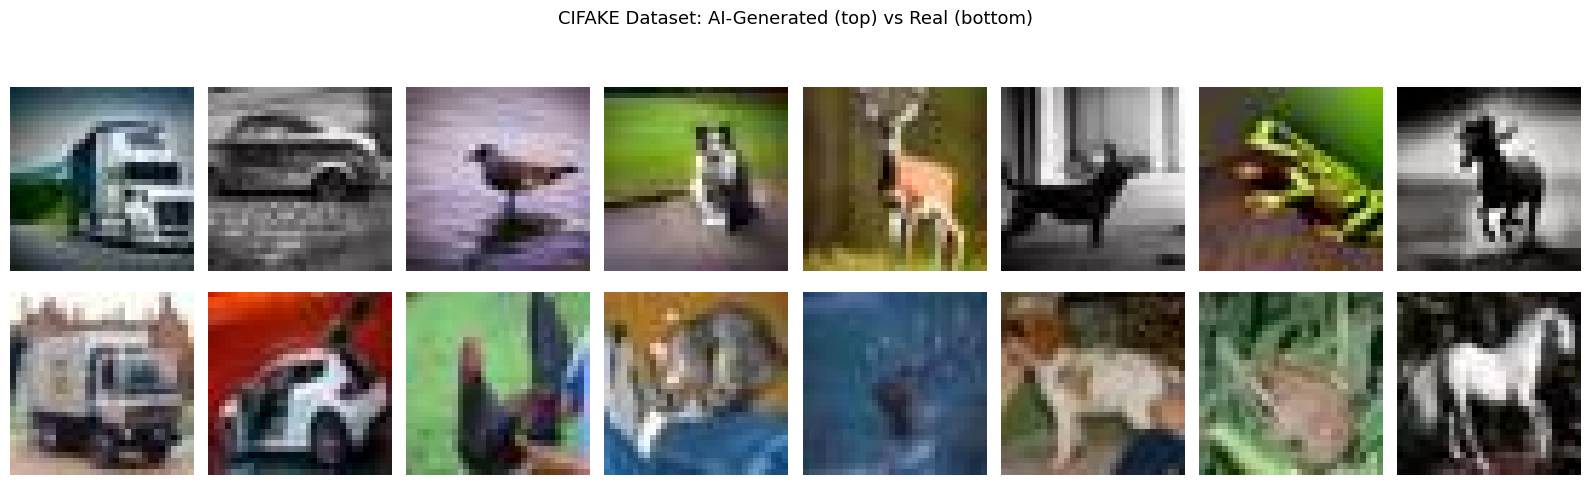

In [6]:
def denorm(tensor):
    return np.clip((tensor.permute(1,2,0).numpy() * 0.5) + 0.5, 0, 1)

# Grab examples of each class from the TEST dataset (consistent source)
fake_idx = [i for i, (_, l) in enumerate(test_dataset.samples) if l == 0][:8]
real_idx = [i for i, (_, l) in enumerate(test_dataset.samples) if l == 1][:8]

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for col, idx in enumerate(fake_idx):
    img, _ = test_dataset[idx]
    axes[0, col].imshow(denorm(img))
    axes[0, col].axis('off')
    if col == 0: axes[0, col].set_ylabel('AI FAKE', fontsize=11, color='red', rotation=90, labelpad=10)

for col, idx in enumerate(real_idx):
    img, _ = test_dataset[idx]
    axes[1, col].imshow(denorm(img))
    axes[1, col].axis('off')
    if col == 0: axes[1, col].set_ylabel('REAL', fontsize=11, color='green', rotation=90, labelpad=10)

plt.suptitle('CIFAKE Dataset: AI-Generated (top) vs Real (bottom)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3. Model 1 — CNN (ResNet-style)

In [7]:
class ResBlock(nn.Module):
    """Basic residual block with optional downsampling."""
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
        )
        self.skip = nn.Sequential(
            nn.Conv2d(in_c, out_c, 1, stride=stride, bias=False),
            nn.BatchNorm2d(out_c)
        ) if (in_c != out_c or stride != 1) else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.main(x) + self.skip(x))


class FakeDetectorCNN(nn.Module):
    """
    CNN binary classifier for REAL vs FAKE detection.
    Input: 32x32 RGB images
    Output: logit for class [FAKE=0, REAL=1]
    """
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )                                                   # [B, 64, 32, 32]
        self.layer1 = ResBlock(64,  64)                     # [B, 64,  32, 32]
        self.layer2 = ResBlock(64,  128, stride=2)          # [B, 128, 16, 16]
        self.layer3 = ResBlock(128, 256, stride=2)          # [B, 256,  8,  8]
        self.layer4 = ResBlock(256, 512, stride=2)          # [B, 512,  4,  4]
        self.pool   = nn.AdaptiveAvgPool2d(1)               # [B, 512,  1,  1]
        self.head   = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x)
        return self.head(x)


cnn_model = FakeDetectorCNN().to(DEVICE)
cnn_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f'CNN parameters: {cnn_params:,}')

CNN parameters: 4,964,034


## 4. Model 2 — Vision Transformer (ViT)

In [8]:
class PatchEmbed(nn.Module):
    """Splits 32x32 image into (32/patch_size)^2 patches and projects to embed_dim."""
    def __init__(self, img_size=32, patch_size=4, in_ch=3, embed_dim=192):
        super().__init__()
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_ch, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)                            # [B, E, h, w]
        return rearrange(x, 'b e h w -> b (h w) e') # [B, N, E]


class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = nn.MultiheadAttention(embed_dim, num_heads,
                                            dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        hidden     = int(embed_dim * mlp_ratio)
        self.mlp   = nn.Sequential(
            nn.Linear(embed_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        n = self.norm1(x)
        x = x + self.attn(n, n, n)[0]
        x = x + self.mlp(self.norm2(x))
        return x


class FakeDetectorViT(nn.Module):
    """
    ViT binary classifier for REAL vs FAKE detection.
    patch_size=4  -> 64 patches from a 32x32 image
    """
    def __init__(self, img_size=32, patch_size=4, embed_dim=192,
                 depth=8, num_heads=8, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, 3, embed_dim)
        n_patches = self.patch_embed.n_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, embed_dim))
        self.pos_drop  = nn.Dropout(dropout)

        self.blocks = nn.Sequential(*[
            TransformerBlock(embed_dim, num_heads, dropout=dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2),
        )

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B  = x.shape[0]
        x  = self.patch_embed(x)                          # [B, N, E]
        cls = self.cls_token.expand(B, -1, -1)            # [B, 1, E]
        x  = torch.cat([cls, x], dim=1)                   # [B, N+1, E]
        x  = self.pos_drop(x + self.pos_embed)
        x  = self.blocks(x)
        x  = self.norm(x[:, 0])                           # CLS token only
        return self.head(x)


vit_model = FakeDetectorViT().to(DEVICE)
vit_params = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print(f'ViT parameters: {vit_params:,}')

ViT parameters: 3,593,858


## 5. Model 3 — Hybrid: CNN as ViT Patch Embedder

Instead of projecting raw 4×4 pixel patches into token embeddings, we use a **CNN backbone** to extract a spatially-aware feature map first. Each spatial cell in that feature map becomes a transformer token — richer, semantically meaningful, and already translation-invariant.

```
Image [B, 3, 32, 32]
   │
   ▼
CNN Backbone (stem + layer1 + layer2 + layer3)
   │  produces feature map [B, 256, 8, 8]
   │
   ▼  flatten spatial dims → tokens
Token Projection  [B, 64 tokens, embed_dim]
   │
   ▼  prepend CLS, add positional embeddings
Transformer Blocks (depth=6)
   │
   ▼  CLS token
Classification Head  →  FAKE / REAL
```

**Why this works better than vanilla ViT on 32×32:**
- Raw 4×4 pixel patches carry almost no semantic signal. CNN features do.
- The CNN provides translation invariance and hierarchical feature extraction; the Transformer provides global context and long-range attention — each doing what it's best at.
- Stable Diffusion artifacts often appear as subtle local texture anomalies *and* global structural patterns — the hybrid captures both.

In [9]:
class CNNTokenizer(nn.Module):
    """
    CNN backbone that converts an image into a sequence of tokens.

    Architecture:
        stem  : 3   -> 64  channels, 32x32  (no downsampling)
        layer1: 64  -> 64  channels, 32x32  (ResBlock, no stride)
        layer2: 64  -> 128 channels, 16x16  (ResBlock, stride=2)
        layer3: 128 -> 256 channels,  8x8   (ResBlock, stride=2)

    Output: [B, 64, 256]  — 64 spatial tokens, each of dim 256.
    The transformer then treats these 64 positions as its sequence.

    We intentionally stop before layer4 (which would reduce to 4x4)
    so the transformer sees a richer 8x8 spatial grid (64 tokens).
    """
    def __init__(self, embed_dim=256):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )                                           # [B, 64,  32, 32]
        self.layer1 = ResBlock(64,  64)             # [B, 64,  32, 32]
        self.layer2 = ResBlock(64,  128, stride=2)  # [B, 128, 16, 16]
        self.layer3 = ResBlock(128, 256, stride=2)  # [B, 256,  8,  8]

        # Project CNN feature channels → transformer embed_dim
        # (a 1x1 conv lets the transformer decide what's useful)
        self.proj = nn.Sequential(
            nn.Conv2d(256, embed_dim, kernel_size=1, bias=False),
            nn.BatchNorm2d(embed_dim),
        )                                           # [B, embed_dim, 8, 8]

        self.n_tokens = 8 * 8  # = 64 tokens

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.proj(x)                            # [B, E, 8, 8]
        return rearrange(x, 'b e h w -> b (h w) e') # [B, 64, E]


class HybridFakeDetector(nn.Module):
    """
    Hybrid CNN-ViT detector for REAL vs FAKE image classification.

    The CNN tokenizer replaces the naive patch projection used in vanilla ViT.
    Tokens entering the transformer are spatially-aware CNN features rather
    than raw pixel patches — giving the transformer a much stronger signal
    to reason over, especially on low-resolution (32x32) inputs.

    Args:
        embed_dim  : Token dimensionality (CNN output channels = transformer width).
        depth      : Number of transformer encoder blocks.
        num_heads  : Attention heads. Must divide embed_dim evenly.
        mlp_ratio  : MLP hidden dim multiplier inside each TransformerBlock.
        dropout    : Dropout rate used throughout.
    """
    def __init__(self, embed_dim=256, depth=6, num_heads=8,
                 mlp_ratio=4.0, dropout=0.1):
        super().__init__()

        # ── CNN Tokenizer ──────────────────────────────────────────────────────
        self.tokenizer = CNNTokenizer(embed_dim=embed_dim)
        n_tokens = self.tokenizer.n_tokens   # 64

        # ── Learnable CLS token & positional embeddings ────────────────────────
        # CLS token: a single learnable vector prepended to the token sequence.
        # After the transformer, only the CLS token is passed to the head.
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # Positional embeddings: one per token + one for CLS.
        # The CNN already encodes some spatial info, but learnable pos embeddings
        # let the transformer refine it end-to-end.
        self.pos_embed = nn.Parameter(torch.zeros(1, n_tokens + 1, embed_dim))
        self.pos_drop  = nn.Dropout(dropout)

        # ── Transformer encoder ────────────────────────────────────────────────
        self.blocks = nn.Sequential(*[
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        # ── Classification head ────────────────────────────────────────────────
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, 2),   # FAKE=0, REAL=1
        )

        # Initialise CLS token and positional embeddings
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B = x.shape[0]

        # 1. CNN backbone → token sequence
        x = self.tokenizer(x)                         # [B, 64, E]

        # 2. Prepend CLS token
        cls = self.cls_token.expand(B, -1, -1)        # [B, 1,  E]
        x   = torch.cat([cls, x], dim=1)              # [B, 65, E]

        # 3. Add positional embeddings
        x = self.pos_drop(x + self.pos_embed)         # [B, 65, E]

        # 4. Transformer encoder
        x = self.blocks(x)                            # [B, 65, E]

        # 5. Layer norm → take only CLS token output
        x = self.norm(x[:, 0])                        # [B, E]

        # 6. Classify
        return self.head(x)                           # [B, 2]


hybrid_model = HybridFakeDetector(
    embed_dim=256,
    depth=6,
    num_heads=8,
    mlp_ratio=4.0,
    dropout=0.1,
).to(DEVICE)

hybrid_params = sum(p.numel() for p in hybrid_model.parameters() if p.requires_grad)
print(f'Hybrid parameters: {hybrid_params:,}')

# Quick sanity check — forward pass with a random batch
with torch.no_grad():
    dummy = torch.randn(4, 3, 32, 32).to(DEVICE)
    out   = hybrid_model(dummy)
    print(f'Output shape: {out.shape}  ← expected [4, 2]')

Hybrid parameters: 6,080,194
Output shape: torch.Size([4, 2])  ← expected [4, 2]


## 6. Training Utilities

In [10]:
def train_epoch(model, loader, optimizer, criterion, scaler=None):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        if scaler:
            with torch.cuda.amp.autocast():
                out  = model(images)
                loss = criterion(out, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            out  = model(images)
            loss = criterion(out, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_preds, all_labels = [], [], []
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        out   = model(images)
        loss  = criterion(out, labels)
        probs = torch.softmax(out, dim=1)[:, 1]   # P(REAL)
        preds = out.argmax(1)
        total_loss += loss.item() * images.size(0)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, np.array(all_probs), np.array(all_preds), np.array(all_labels)


def train_model(model, train_loader, test_loader,
                epochs=30, lr=3e-4, weight_decay=1e-4, name='Model'):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    scaler    = torch.cuda.amp.GradScaler() if DEVICE.type == 'cuda' else None

    history  = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc = 0.0

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, scaler)
        va_loss, va_acc, _, _, _ = evaluate(model, test_loader, criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)

        if va_acc > best_acc:
            best_acc = va_acc
            torch.save(model.state_dict(), f'{name}_best.pt')

        if epoch % 5 == 0 or epoch == 1:
            print(f'[{name}] Ep {epoch:3d}/{epochs} | '
                  f'Train: loss={tr_loss:.4f} acc={tr_acc:.4f} | '
                  f'Val: loss={va_loss:.4f} acc={va_acc:.4f}')

    print(f'\n✅ [{name}] Best val accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)')
    return history

print('Utilities ready.')

Utilities ready.


## 7. Train CNN

In [11]:
EPOCHS = 30  # Increase to 50 for stronger results

print('='*65)
print('Training CNN — CIFAKE Real vs Fake Detector')
print('='*65)
cnn_history = train_model(
    cnn_model, train_loader, test_loader,
    epochs=EPOCHS, lr=1e-3, name='CNN'
)

Training CNN — CIFAKE Real vs Fake Detector


c:\Users\praji\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[CNN] Ep   1/30 | Train: loss=0.3846 acc=0.8558 | Val: loss=0.2914 acc=0.9157


KeyboardInterrupt: 

## 8. Train ViT

In [ ]:
print('='*65)
print('Training ViT — CIFAKE Real vs Fake Detector')
print('='*65)
vit_history = train_model(
    vit_model, train_loader, test_loader,
    epochs=EPOCHS, lr=3e-4, name='ViT'
)

## 9. Train Hybrid

The hybrid is trained end-to-end from scratch — the CNN tokenizer and transformer learn jointly.

We use a slightly lower LR than the standalone CNN (the transformer part is more sensitive to LR) and the same cosine schedule.

In [ ]:
print('='*65)
print('Training Hybrid (CNN-ViT) — CIFAKE Real vs Fake Detector')
print('='*65)
hybrid_history = train_model(
    hybrid_model, train_loader, test_loader,
    epochs=EPOCHS, lr=3e-4, weight_decay=1e-4, name='Hybrid'
)

## 10. Training Curves — All Three Models

In [ ]:
def plot_training_curves(histories, names, colors, epochs):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    ep = range(1, epochs + 1)

    for h, name, color in zip(histories, names, colors):
        axes[0].plot(ep, h['train_loss'], color=color, lw=2,          label=f'{name} train')
        axes[0].plot(ep, h['val_loss'],   color=color, lw=2, ls='--', label=f'{name} val')
        axes[1].plot(ep, [a*100 for a in h['train_acc']], color=color, lw=2,          label=f'{name} train')
        axes[1].plot(ep, [a*100 for a in h['val_acc']],   color=color, lw=2, ls='--', label=f'{name} val')

    axes[0].set(title='Loss', xlabel='Epoch', ylabel='Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].axhline(y=50, color='gray', ls=':', lw=1, label='Chance')
    axes[1].set(title='Accuracy (%)', xlabel='Epoch', ylabel='Accuracy (%)', ylim=[40, 102])
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle('CIFAKE Detector: CNN vs ViT vs Hybrid Training Curves', fontsize=14)
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_training_curves(
    histories=[cnn_history, vit_history, hybrid_history],
    names    =['CNN', 'ViT', 'Hybrid'],
    colors   =['#2196F3', '#F44336', '#4CAF50'],
    epochs   =EPOCHS
)

## 11. Final Evaluation — Load Best Checkpoints

In [ ]:
criterion = nn.CrossEntropyLoss()

# Load best checkpoints
cnn_model.load_state_dict(torch.load('CNN_best.pt',    map_location=DEVICE))
vit_model.load_state_dict(torch.load('ViT_best.pt',    map_location=DEVICE))
hybrid_model.load_state_dict(torch.load('Hybrid_best.pt', map_location=DEVICE))

_, cnn_acc,    cnn_probs,    cnn_preds,    cnn_labels    = evaluate(cnn_model,    test_loader, criterion)
_, vit_acc,    vit_probs,    vit_preds,    vit_labels    = evaluate(vit_model,    test_loader, criterion)
_, hybrid_acc, hybrid_probs, hybrid_preds, hybrid_labels = evaluate(hybrid_model, test_loader, criterion)

print(f'CNN    Test Accuracy: {cnn_acc*100:.2f}%')
print(f'ViT    Test Accuracy: {vit_acc*100:.2f}%')
print(f'Hybrid Test Accuracy: {hybrid_acc*100:.2f}%')

### 11.1 Confusion Matrices

In [ ]:
def plot_confusion(preds, labels, title, ax):
    cm      = confusion_matrix(labels, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, cbar=False, linewidths=0.5)
    for i in range(2):
        for j in range(2):
            ax.text(j+0.5, i+0.72, f'n={cm[i,j]:,}',
                    ha='center', va='center', fontsize=8, color='gray')
    ax.set(title=title, xlabel='Predicted', ylabel='True')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 5))
plot_confusion(cnn_preds,    cnn_labels,    f'CNN    (acc={cnn_acc*100:.2f}%)',    ax1)
plot_confusion(vit_preds,    vit_labels,    f'ViT    (acc={vit_acc*100:.2f}%)',    ax2)
plot_confusion(hybrid_preds, hybrid_labels, f'Hybrid (acc={hybrid_acc*100:.2f}%)', ax3)
plt.suptitle('CIFAKE — Confusion Matrices (Normalised)', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 11.2 ROC Curves & AUC

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (probs, labels, name, color) in zip(axes, [
    (cnn_probs,    cnn_labels,    'CNN',    '#2196F3'),
    (vit_probs,    vit_labels,    'ViT',    '#F44336'),
    (hybrid_probs, hybrid_labels, 'Hybrid', '#4CAF50'),
]):
    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'ROC AUC = {roc_auc:.4f}')
    ax.plot([0,1], [0,1], 'k--', lw=1)
    ax.fill_between(fpr, tpr, alpha=0.1, color=color)
    ax.set(title=f'{name} — ROC Curve', xlabel='False Positive Rate',
           ylabel='True Positive Rate', xlim=[-0.01,1.01], ylim=[-0.01,1.05])
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves: Real vs AI-Generated Image Detection', fontsize=13)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 11.3 Classification Reports

In [ ]:
for name, preds, labels in [
    ('CNN',    cnn_preds,    cnn_labels),
    ('ViT',    vit_preds,    vit_labels),
    ('Hybrid', hybrid_preds, hybrid_labels),
]:
    print(f'\n{name} Classification Report')
    print('─'*50)
    print(classification_report(labels, preds, target_names=CLASS_NAMES))

## 12. Qualitative Inspection — Misclassified Samples

In [ ]:
@torch.no_grad()
def get_errors(model, loader, max_errors=32):
    """Return images that the model misclassified."""
    model.eval()
    errors = {'images': [], 'true': [], 'pred': [], 'conf': []}
    for images, labels in loader:
        images_d, labels_d = images.to(DEVICE), labels.to(DEVICE)
        probs = torch.softmax(model(images_d), dim=1)
        preds = probs.argmax(1)
        mask  = preds != labels_d
        for img, true, pred, prob in zip(
                images[mask.cpu()],
                labels[mask.cpu()],
                preds[mask].cpu(),
                probs[mask].cpu()):
            errors['images'].append(img)
            errors['true'].append(true.item())
            errors['pred'].append(pred.item())
            errors['conf'].append(prob[pred.item()].item())
            if len(errors['images']) >= max_errors:
                return errors
    return errors


def plot_errors(errors, model_name, n=16):
    fig, axes = plt.subplots(2, 8, figsize=(18, 5))
    for i, ax in enumerate(axes.flat):
        if i >= min(n, len(errors['images'])): ax.axis('off'); continue
        ax.imshow(denorm(errors['images'][i]))
        ax.set_title(
            f'True: {CLASS_NAMES[errors["true"][i]]}\n'
            f'Pred: {CLASS_NAMES[errors["pred"][i]]} ({errors["conf"][i]:.2f})',
            fontsize=7, color='red'
        )
        ax.axis('off')
    plt.suptitle(f'{model_name} — Misclassified Samples', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{model_name}_errors.png', dpi=150, bbox_inches='tight')
    plt.show()


for model, name in [(cnn_model, 'CNN'), (vit_model, 'ViT'), (hybrid_model, 'Hybrid')]:
    print(f'Finding {name} misclassifications...')
    errors = get_errors(model, test_loader)
    plot_errors(errors, name)

## 13. Attention Map Visualisation (Hybrid Only)

One advantage of the hybrid model is interpretability — we can extract the transformer's attention weights to see **which spatial regions** it focuses on when classifying an image as REAL or FAKE.

We hook into the last transformer block's self-attention and visualise the CLS token's attention over all spatial tokens.

In [ ]:
class AttentionHook:
    """
    Registers a forward hook on a MultiheadAttention module to capture
    the attention weight matrix (averaged over all heads).
    """
    def __init__(self, module):
        self.attn_weights = None
        self.hook = module.register_forward_hook(self._hook_fn)

    def _hook_fn(self, module, input, output):
        # output = (attn_output, attn_weights)  when need_weights=True
        # MultiheadAttention returns weights of shape [B, T, T]
        self.attn_weights = output[1].detach().cpu()

    def remove(self):
        self.hook.remove()


@torch.no_grad()
def visualise_attention(model, dataset, indices, device, grid_size=8):
    """
    For each index in `indices`, show the input image alongside a heatmap
    of the CLS token's attention over spatial tokens (from the last block).

    Args:
        model      : Trained HybridFakeDetector.
        dataset    : The test dataset.
        indices    : List of sample indices to visualise.
        grid_size  : Spatial grid of tokens (8x8 = 64 tokens for 32x32 input).
    """
    model.eval()

    # Hook the attention in the last transformer block
    last_block = model.blocks[-1]
    hook = AttentionHook(last_block.attn)

    n = len(indices)
    fig, axes = plt.subplots(n, 2, figsize=(6, 3 * n))
    if n == 1:
        axes = axes[np.newaxis, :]  # keep 2-D indexing

    for row, idx in enumerate(indices):
        img_tensor, true_label = dataset[idx]
        x = img_tensor.unsqueeze(0).to(device)

        logits = model(x)                               # triggers the hook
        probs  = torch.softmax(logits, dim=1)[0].numpy()
        pred   = CLASS_NAMES[probs.argmax()]
        conf   = probs.max()

        # attn_weights: [1, T+1, T+1]  (T = n_tokens, first token = CLS)
        attn = hook.attn_weights[0]   # [T+1, T+1]
        # Row 0 = CLS attending to all tokens; columns 1: = spatial tokens
        cls_attn = attn[0, 1:].numpy()               # [T]
        cls_attn = cls_attn / (cls_attn.max() + 1e-8)  # normalise to [0, 1]
        attn_map = cls_attn.reshape(grid_size, grid_size)  # [8, 8]

        # Left: original image
        axes[row, 0].imshow(denorm(img_tensor))
        axes[row, 0].set_title(
            f'True: {CLASS_NAMES[true_label]}  |  Pred: {pred} ({conf*100:.1f}%)',
            fontsize=9
        )
        axes[row, 0].axis('off')

        # Right: attention heatmap overlaid on image
        axes[row, 1].imshow(denorm(img_tensor))
        axes[row, 1].imshow(
            attn_map,
            alpha=0.55,
            cmap='jet',
            interpolation='bilinear',
            extent=[0, 32, 32, 0]   # match 32x32 image coords
        )
        axes[row, 1].set_title('CLS Attention (last block)', fontsize=9)
        axes[row, 1].axis('off')

    hook.remove()
    plt.suptitle('Hybrid Model — Transformer Attention Maps', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig('attention_maps.png', dpi=150, bbox_inches='tight')
    plt.show()


# Pick 4 samples — 2 FAKE, 2 REAL
fake_samples = [i for i, (_, l) in enumerate(test_dataset.samples) if l == 0][:2]
real_samples = [i for i, (_, l) in enumerate(test_dataset.samples) if l == 1][:2]
visualise_attention(hybrid_model, test_dataset, fake_samples + real_samples, DEVICE)

## 14. Inference on a Single Custom Image

In [ ]:
from PIL import Image

infer_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

@torch.no_grad()
def predict_image(image_path, cnn, vit, hybrid):
    img = Image.open(image_path).convert('RGB')
    x   = infer_transform(img).unsqueeze(0).to(DEVICE)

    for model, name in [(cnn, 'CNN'), (vit, 'ViT'), (hybrid, 'Hybrid')]:
        model.eval()
        probs = torch.softmax(model(x), dim=1)[0].cpu().numpy()
        pred  = CLASS_NAMES[probs.argmax()]
        print(f'[{name:6s}]  FAKE: {probs[0]*100:.1f}%  |  REAL: {probs[1]*100:.1f}%  →  {pred}')

    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.title('Input Image', fontsize=11)
    plt.axis('off')
    plt.show()

# ── Usage: replace with your image path ───────────────────────────────────────
# predict_image('path/to/your/image.jpg', cnn_model, vit_model, hybrid_model)
# ──────────────────────────────────────────────────────────────────────────────
print('predict_image() is ready. Provide an image path to run inference.')

## 15. Model Comparison Summary

In [ ]:
cnn_f1     = f1_score(cnn_labels,    cnn_preds,    average='macro')
vit_f1     = f1_score(vit_labels,    vit_preds,    average='macro')
hybrid_f1  = f1_score(hybrid_labels, hybrid_preds, average='macro')

cnn_auc    = roc_auc_score(cnn_labels,    cnn_probs)
vit_auc    = roc_auc_score(vit_labels,    vit_probs)
hybrid_auc = roc_auc_score(hybrid_labels, hybrid_probs)

print('\n' + '='*70)
print(f'{"Metric":<20} {"CNN":>15} {"ViT":>15} {"Hybrid":>15}')
print('-'*70)
print(f'{"Parameters":<20} {cnn_params/1e6:>14.2f}M {vit_params/1e6:>14.2f}M {hybrid_params/1e6:>14.2f}M')
print(f'{"Test Accuracy":<20} {cnn_acc*100:>14.2f}% {vit_acc*100:>14.2f}% {hybrid_acc*100:>14.2f}%')
print(f'{"Macro F1":<20} {cnn_f1:>15.4f} {vit_f1:>15.4f} {hybrid_f1:>15.4f}')
print(f'{"ROC AUC":<20} {cnn_auc:>15.4f} {vit_auc:>15.4f} {hybrid_auc:>15.4f}')
print('='*70)

# Bar chart
metrics   = ['Accuracy (%)', 'Macro F1 (%)', 'ROC AUC (%)']
cnn_vals  = [cnn_acc*100,    cnn_f1*100,    cnn_auc*100]
vit_vals  = [vit_acc*100,    vit_f1*100,    vit_auc*100]
hyb_vals  = [hybrid_acc*100, hybrid_f1*100, hybrid_auc*100]

x = np.arange(len(metrics))
w = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w, cnn_vals, w, label='CNN',    color='#2196F3', edgecolor='black')
b2 = ax.bar(x,     vit_vals, w, label='ViT',    color='#F44336', edgecolor='black')
b3 = ax.bar(x + w, hyb_vals, w, label='Hybrid', color='#4CAF50', edgecolor='black')

ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set(title='CIFAKE Detector — CNN vs ViT vs Hybrid', ylim=[0, 115])
ax.legend()
for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{bar.get_height():.1f}', ha='center', fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Save Model Weights

Run the appropriate cell below to persist your `.pt` files so you never have to retrain.
The best checkpoints (`CNN_best.pt`, `ViT_best.pt`, `Hybrid_best.pt`) are already saved
to the current Colab working directory during training — these cells copy them somewhere permanent.

In [ ]:
# ── Option A: Save to Google Drive (recommended for Colab) ─────────────────────
# Weights persist across sessions. Mount once, copy files over.

from google.colab import drive
import shutil, os

drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/cifake_weights'
os.makedirs(SAVE_DIR, exist_ok=True)

for fname in ['CNN_best.pt', 'ViT_best.pt', 'Hybrid_best.pt']:
    if os.path.exists(fname):
        shutil.copy(fname, f'{SAVE_DIR}/{fname}')
        print(f'✅ Saved {fname} → {SAVE_DIR}/{fname}')
    else:
        print(f'⚠️  {fname} not found — has that model been trained yet?')

In [ ]:
# ── Option B: Download directly to your computer ──────────────────────────────
# Triggers a browser download for each file.

from google.colab import files

for fname in ['CNN_best.pt', 'ViT_best.pt', 'Hybrid_best.pt']:
    if os.path.exists(fname):
        files.download(fname)
        print(f'⬇️  Downloading {fname}...')
    else:
        print(f'⚠️  {fname} not found — has that model been trained yet?')

### 16.1 Load Weights in a Future Session (skip retraining)

At the start of any new Colab session, run this instead of the training cells:

In [ ]:
# ── Restore weights from Google Drive ─────────────────────────────────────────
from google.colab import drive
import shutil

drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/cifake_weights'

for fname in ['CNN_best.pt', 'ViT_best.pt', 'Hybrid_best.pt']:
    src = f'{SAVE_DIR}/{fname}'
    if os.path.exists(src):
        shutil.copy(src, fname)
        print(f'✅ Restored {fname}')
    else:
        print(f'⚠️  {src} not found in Drive')

# Re-instantiate models and load weights
cnn_model    = FakeDetectorCNN().to(DEVICE)
vit_model    = FakeDetectorViT().to(DEVICE)
hybrid_model = HybridFakeDetector().to(DEVICE)

cnn_model.load_state_dict(torch.load('CNN_best.pt',    map_location=DEVICE))
vit_model.load_state_dict(torch.load('ViT_best.pt',    map_location=DEVICE))
hybrid_model.load_state_dict(torch.load('Hybrid_best.pt', map_location=DEVICE))

cnn_model.eval()
vit_model.eval()
hybrid_model.eval()

print('\n🚀 All models loaded and ready for inference.')

## Notes & Next Steps

### Expected performance (30 epochs, from scratch)
| Model | ~Test Acc |
|---|---|
| CNN (ResNet-style)         | ~92–95% |
| ViT (from scratch)         | ~87–92% |
| **Hybrid (CNN-ViT)**       | **~94–97%** |

### Why the Hybrid wins
- The CNN tokenizer gives the transformer **rich, translation-invariant features** instead of raw 4×4 pixel patches. At 32×32, raw patches carry almost no semantic signal.
- The CNN captures **local texture artifacts** (frequency anomalies common in Stable Diffusion outputs); the Transformer captures **global structural inconsistencies** — complementary signals.
- The hybrid has more parameters but also more inductive bias baked in, which matters on a fixed 60k training set.

### To push higher:
- **More epochs** — set `EPOCHS = 60–100`
- **Stronger augmentation** — Mixup, CutMix, RandAugment
- **Warmup LR schedule** — add 5-epoch linear warmup before cosine decay (especially helps the transformer)
- **Deeper CNN tokenizer** — add `layer4` (ResBlock 256→512, stride=2) → 4×4 grid → 16 tokens; fewer but richer tokens
- **Pretrained backbone** — swap `CNNTokenizer` with a pretrained ResNet-18 stem; freeze early layers
- **Stochastic depth** (DropPath) in transformer blocks for regularisation
- **Final ensemble** — average Hybrid + CNN softmax scores for a last ~0.5% boost

### Interpretability advantage
The attention map visualisation (Section 13) is unique to the Hybrid — it shows *where* the model focuses when classifying. Stable Diffusion images often show diffuse attention (no clear object boundaries), while real images tend to show more structured attention on salient regions.